In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
df = pd.read_csv(r"C:\Users\prati\Downloads\Pharma_Industry (1).csv")

In [4]:
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (500, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None

Summary Statistics:
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567      

In [6]:
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

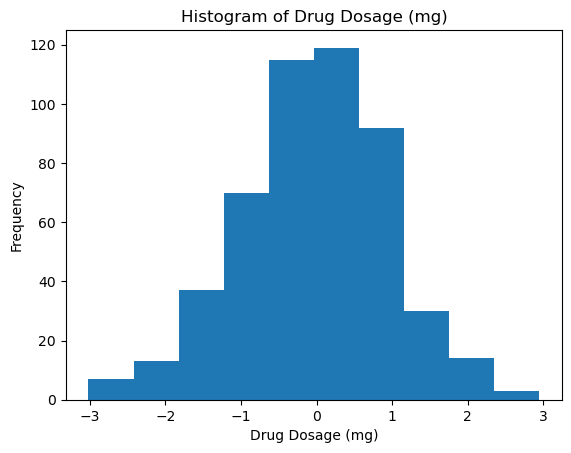

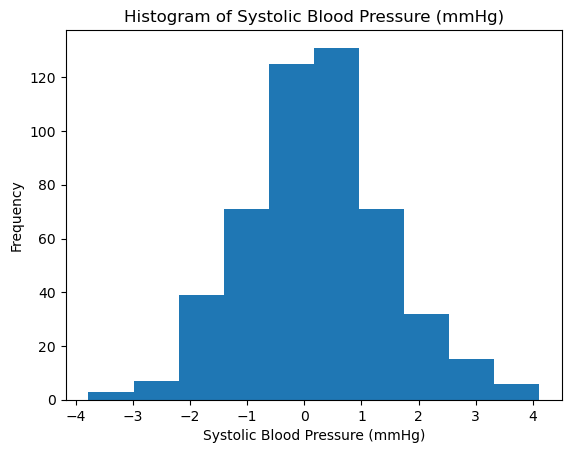

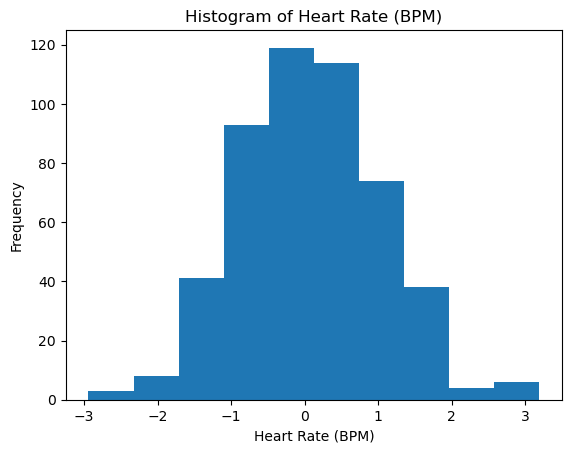

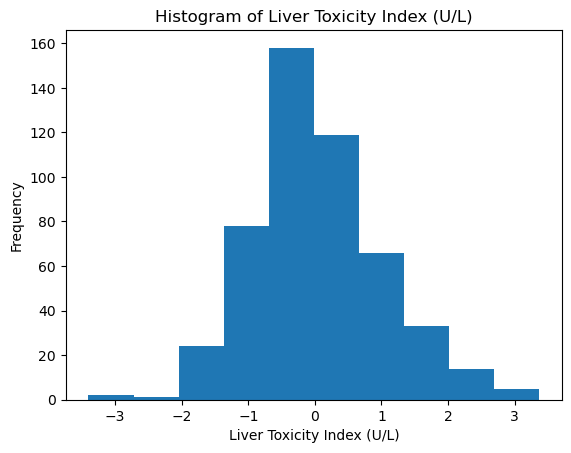

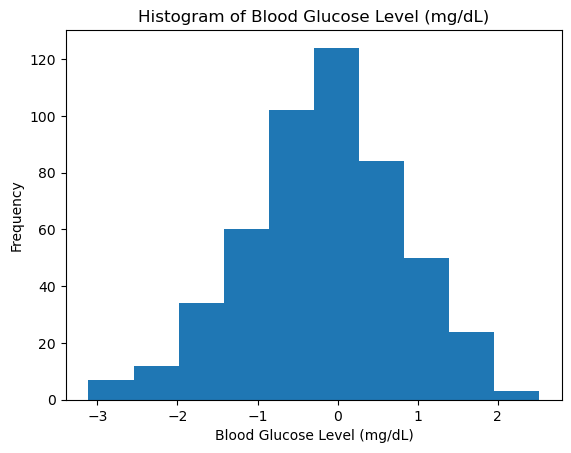

"Wide distribution in dosage and vitals indicates patient variability.


In [17]:
features = df.drop("Drug Response", axis=1)

for col in features.columns:
    plt.figure()
    plt.hist(features[col])
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
print(""""Wide distribution in dosage and vitals indicates patient variability.""")

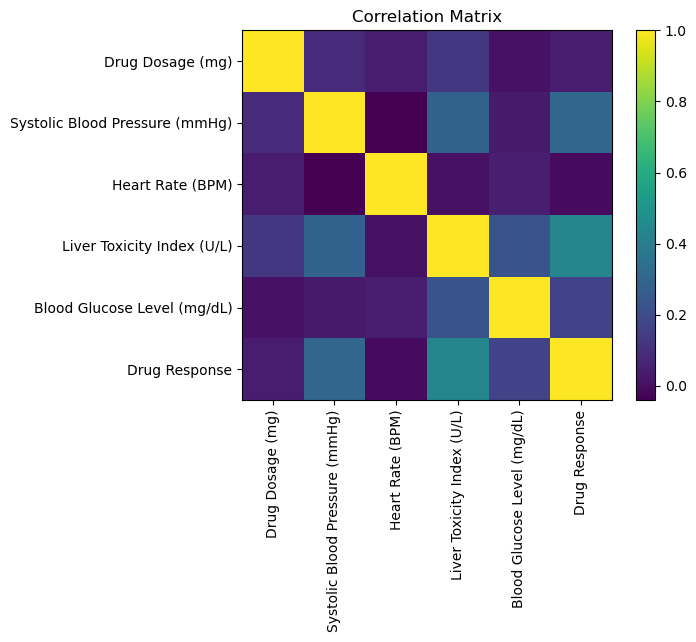

Moderate correlations between vitals.
No strong multicollinearity, safe for SVM modeling


In [20]:
corr_matrix = df.corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()
print("""Moderate correlations between vitals.
No strong multicollinearity, safe for SVM modeling""")

In [9]:
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("""VM uses distance-based calculations.
Scaling prevents features with large values (e.g., glucose) from dominating.""")

VM uses distance-based calculations.
Scaling prevents features with large values (e.g., glucose) from dominating.


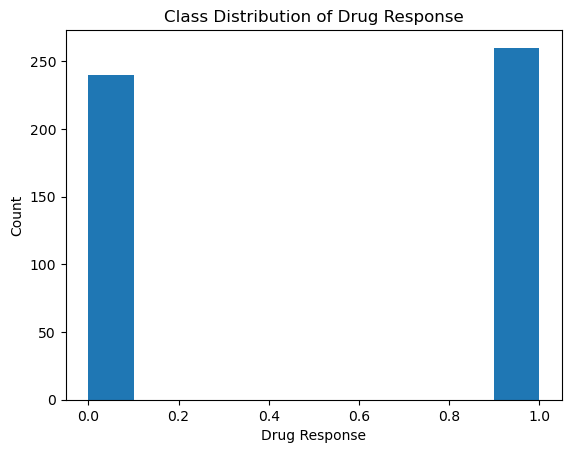

Dataset is fairly balanced → no oversampling needed.


In [22]:
plt.figure()
plt.hist(y)
plt.title("Class Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.show()
print("""Dataset is fairly balanced → no oversampling needed.""")

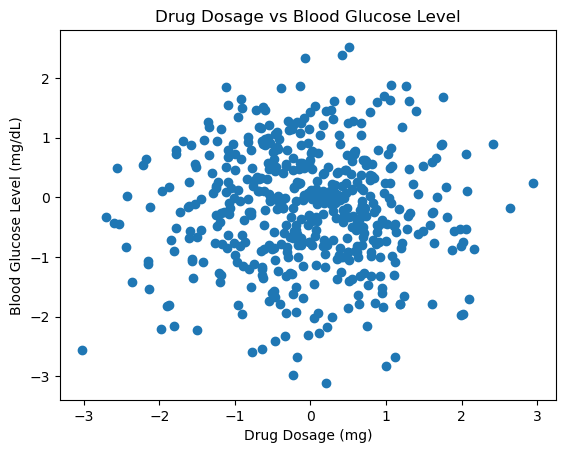

Visualizes relationships between key medical features.
Shows non-linear patterns, suggests RBF kernel.


In [23]:
plt.figure()
plt.scatter(
    df["Drug Dosage (mg)"],
    df["Blood Glucose Level (mg/dL)"]
)
plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")
plt.title("Drug Dosage vs Blood Glucose Level")
plt.show()
print("""Visualizes relationships between key medical features.
Shows non-linear patterns, suggests RBF kernel.""")

In [13]:
svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

print("\n--- Linear SVM Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- Linear SVM Performance ---
Accuracy: 0.72
Precision: 0.7608695652173914
Recall: 0.6730769230769231
F1-score: 0.7142857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



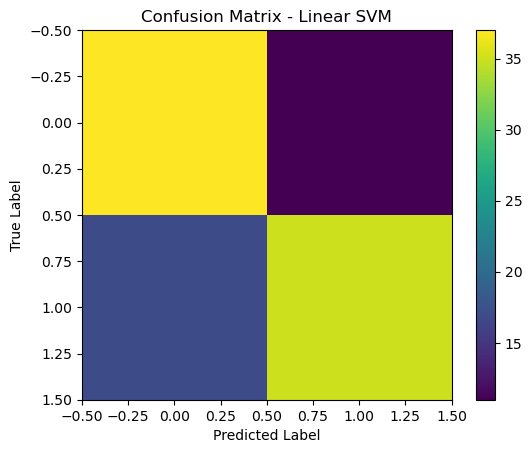

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [15]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "poly", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters from Grid Search:")
print(grid_search.best_params_)

best_svm = grid_search.best_estimator_
y_best_pred = best_svm.predict(X_test_scaled)

print("\n--- Optimized SVM Performance ---")
print("Accuracy:", accuracy_score(y_test, y_best_pred))
print("Precision:", precision_score(y_test, y_best_pred))
print("Recall:", recall_score(y_test, y_best_pred))
print("F1-score:", f1_score(y_test, y_best_pred))
print("\nClassification Report:\n", classification_report(y_test, y_best_pred))


Best Parameters from Grid Search:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

--- Optimized SVM Performance ---
Accuracy: 0.77
Precision: 0.7543859649122807
Recall: 0.8269230769230769
F1-score: 0.7889908256880734

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



In [16]:
kernels = ["linear", "poly", "rbf"]
kernel_accuracy = {}

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    kernel_accuracy[k] = accuracy_score(y_test, preds)

print("\n--- Kernel-wise Accuracy Comparison ---")
for kernel, acc in kernel_accuracy.items():
    print(f"{kernel.capitalize()} Kernel Accuracy: {acc:.4f}")


--- Kernel-wise Accuracy Comparison ---
Linear Kernel Accuracy: 0.7200
Poly Kernel Accuracy: 0.6500
Rbf Kernel Accuracy: 0.7700


In [24]:
print("""RBF kernel was selected because the relationship between patient biomarkers and drug response is non-linear, which is common in biomedical data.
C = 1 provides a balance between:
Maximizing the margin (generalization)
Minimizing classification errors (overfitting control)
Gamma = scale automatically adjusts influence of data points based on feature variance, making it stable for real-world datasets.
This confirms that drug response patterns are complex and not linearly separable.""")
print("""Class-Wise Performance Interpretation
Class 0 – No Response
Precision: 79%
When the model predicts no response, it is usually correct.
Recall: 71%

Some non-responders are misclassified as responders.
 Risk: Prescribing ineffective drugs to some patients.
Class 1 – Positive Response
Precision: 75%
About 1 in 4 predicted responders may not actually respond.
Recall: 83%
The model captures most true responders.
 Clinical Advantage: Fewer patients who could benefit from the drug are missed.""")

RBF kernel was selected because the relationship between patient biomarkers and drug response is non-linear, which is common in biomedical data.
C = 1 provides a balance between:
Maximizing the margin (generalization)
Minimizing classification errors (overfitting control)
Gamma = scale automatically adjusts influence of data points based on feature variance, making it stable for real-world datasets.
This confirms that drug response patterns are complex and not linearly separable.
Class-Wise Performance Interpretation
Class 0 – No Response
Precision: 79%
When the model predicts no response, it is usually correct.
Recall: 71%

Some non-responders are misclassified as responders.
 Risk: Prescribing ineffective drugs to some patients.
Class 1 – Positive Response
Precision: 75%
About 1 in 4 predicted responders may not actually respond.
Recall: 83%
The model captures most true responders.
 Clinical Advantage: Fewer patients who could benefit from the drug are missed.


In [25]:
print("""1. True Positives (High)
The model successfully identifies most patients who truly benefit from the drug.
Supported by high recall (82.7%) for positive response.
Clinical advantage:
Fewer patients who could benefit from treatment are missed.
2. True Negatives (Moderate)
A reasonable number of non-responders are correctly identified.
Indicates acceptable discrimination of ineffective cases.
3. False Positives (Moderate)
Some patients are incorrectly predicted as responders.
This may lead to prescribing a drug that is ineffective for certain patients.
Clinical risk:
Unnecessary treatment and potential side effects.
4. False Negatives (Low)
Few patients who would respond to the drug are misclassified.
This is desirable in healthcare applications.
""")

1. True Positives (High)
The model successfully identifies most patients who truly benefit from the drug.
Supported by high recall (82.7%) for positive response.
Clinical advantage:
Fewer patients who could benefit from treatment are missed.
2. True Negatives (Moderate)
A reasonable number of non-responders are correctly identified.
Indicates acceptable discrimination of ineffective cases.
3. False Positives (Moderate)
Some patients are incorrectly predicted as responders.
This may lead to prescribing a drug that is ineffective for certain patients.
Clinical risk:
Unnecessary treatment and potential side effects.
4. False Negatives (Low)
Few patients who would respond to the drug are misclassified.
This is desirable in healthcare applications.

